# Analyzing Results

In [35]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [36]:
def get_runs(name):
    df = pd.read_csv(f"results/g1000r3/{name}.csv")

    run0 = df[df["run"] == 0].reset_index()
    run1 = df[df["run"] == 1].reset_index()
    run2 = df[df["run"] == 2].reset_index()

    return run0, run1, run2

def plot_frequencies(df, title):
    plt.plot(df["f_L"], label="L frequency")
    plt.plot(df["f_F"], label="F frequency")
    plt.plot(df["f_B"], label="B frequency")
    plt.plot(df["f_C"], label="C frequency")

    plt.legend()
    plt.ylim([0,1])
    plt.xlabel("Generations")
    plt.ylabel("Frequency")
    plt.title(title)

    plt.show()

def plot_env_frequencies(name):
    run0, run1, run2 = get_runs(name)

    avg_run = pd.DataFrame()
    avg_run["f_L"] = pd.concat([run0["f_L"], run1["f_L"], run2["f_L"]], axis=1).mean(axis=1)
    avg_run["f_F"] = pd.concat([run0["f_F"], run1["f_F"], run2["f_F"]], axis=1).mean(axis=1)
    avg_run["f_B"] = pd.concat([run0["f_B"], run1["f_B"], run2["f_B"]], axis=1).mean(axis=1)
    avg_run["f_C"] = pd.concat([run0["f_C"], run1["f_C"], run2["f_C"]], axis=1).mean(axis=1)

    plot_frequencies(avg_run, f"Environment {name}, Mean Positional Frequencies")

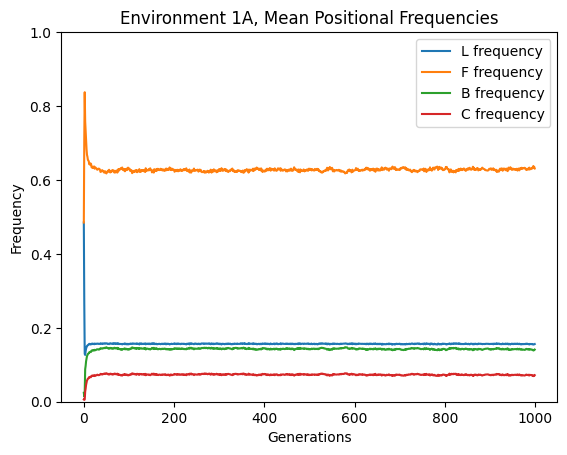

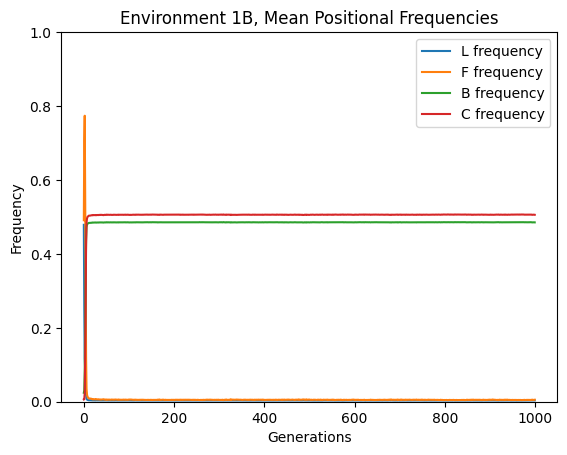

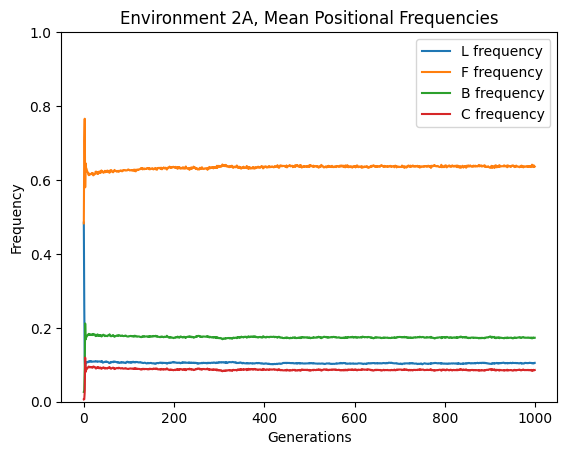

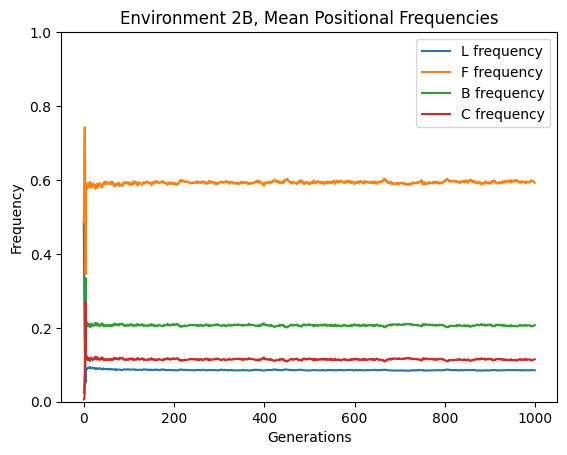

In [37]:
plot_env_frequencies("1A")
plot_env_frequencies("1B")
plot_env_frequencies("2A")
plot_env_frequencies("2B")

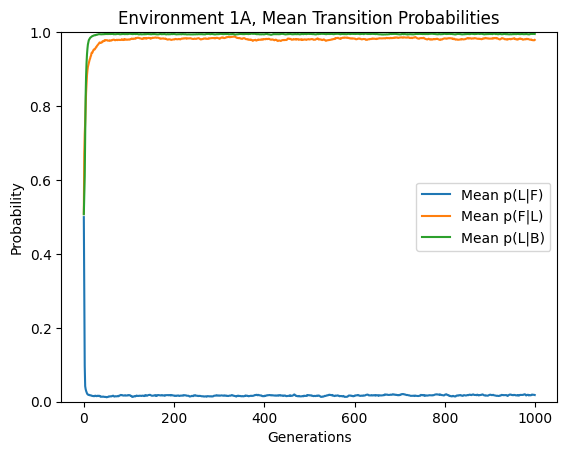

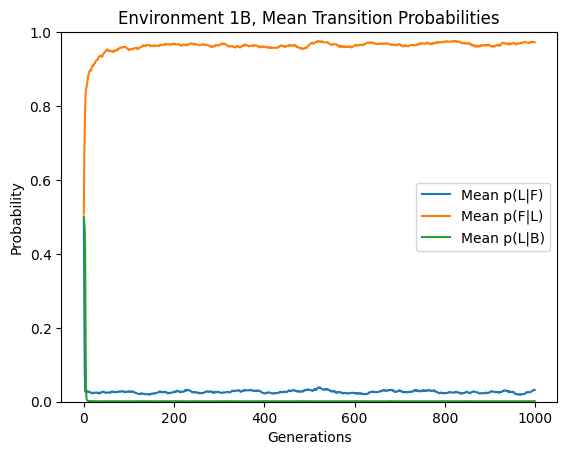

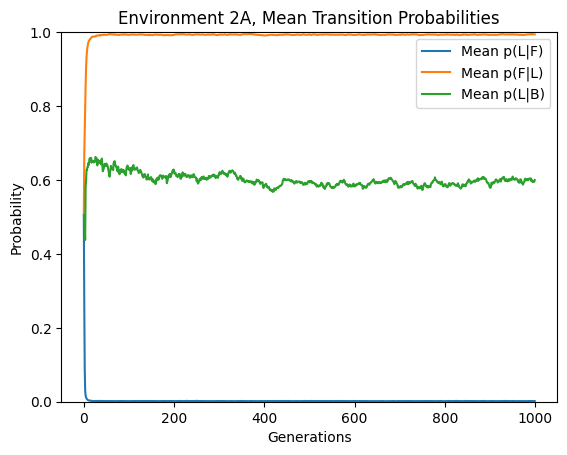

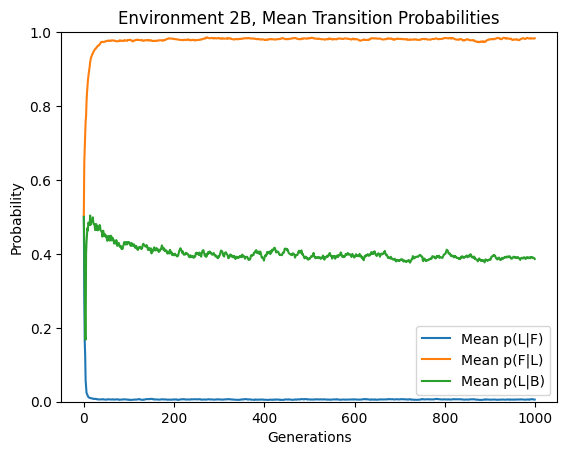

In [38]:
def plot_strategies(df, title):
    plt.plot(df["mean_p_L_given_F"], label="Mean p(L|F)")
    plt.plot(df["mean_p_F_given_L"], label="Mean p(F|L)")
    plt.plot(df["mean_p_L_given_B"], label="Mean p(L|B)")

    plt.legend()
    plt.ylim([0,1])
    plt.xlabel("Generations")
    plt.ylabel("Probability")
    plt.title(title)

    plt.show()

def plot_env_strategies(name):
    run0, run1, run2 = get_runs(name)

    avg_run = pd.DataFrame()
    avg_run["mean_p_L_given_F"] = pd.concat([run0["mean_p_L_given_F"], run1["mean_p_L_given_F"], run2["mean_p_L_given_F"]], axis=1).mean(axis=1)
    avg_run["mean_p_F_given_L"] = pd.concat([run0["mean_p_F_given_L"], run1["mean_p_F_given_L"], run2["mean_p_F_given_L"]], axis=1).mean(axis=1)
    avg_run["mean_p_L_given_B"] = pd.concat([run0["mean_p_L_given_B"], run1["mean_p_L_given_B"], run2["mean_p_L_given_B"]], axis=1).mean(axis=1)

    plot_strategies(avg_run, f"Environment {name}, Mean Transition Probabilities")

plot_env_strategies("1A")
plot_env_strategies("1B")
plot_env_strategies("2A")
plot_env_strategies("2B")

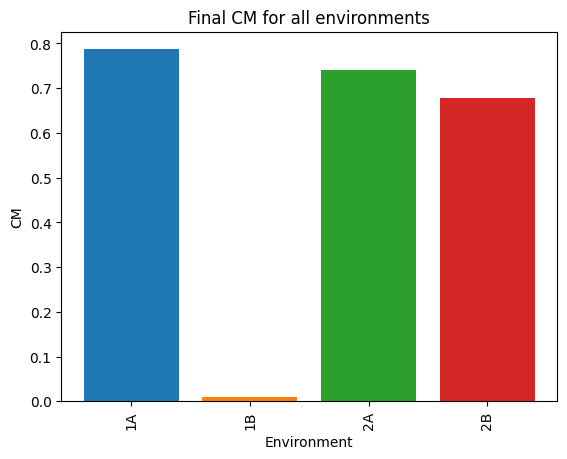

In [39]:
def plot_env_cm(names):

    for name in names:
        run0, run1, run2 = get_runs(name)
        CM = pd.concat([run0["CM"], run1["CM"], run2["CM"]], axis=1).mean(axis=1)
        plt.bar(f"{name}", CM.iloc[-1], label=f"Env {name} CM")

    # plt.legend()
    plt.xticks(rotation=90)
    plt.xlabel("Environment")
    plt.ylabel("CM")
    plt.title("Final CM for all environments")

    plt.show()

plot_env_cm(["1A", "1B", "2A", "2B"])

# Co-evolutionary setting

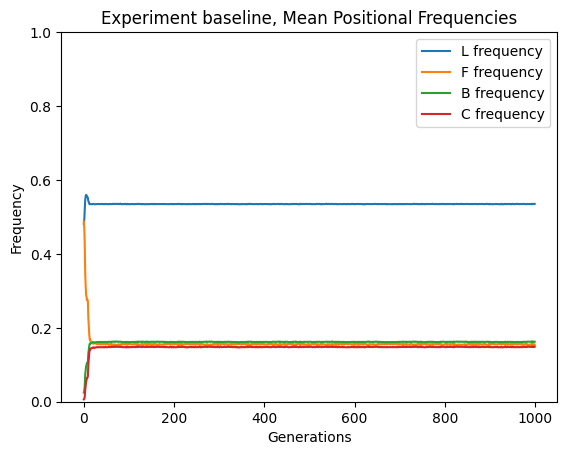

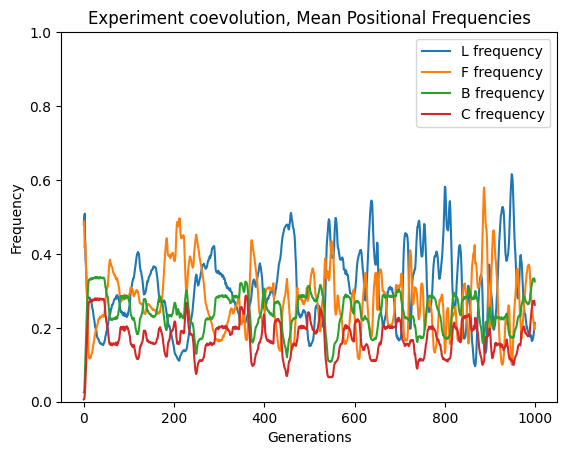

In [40]:
def get_coevo_runs(name):
    df = pd.read_csv(name)

    run0 = df[df["run"] == 0].reset_index()
    run1 = df[df["run"] == 1].reset_index()
    run2 = df[df["run"] == 2].reset_index()
    run3 = df[df["run"] == 3].reset_index()

    return run0, run1, run2, run3

def plot_coevo_frequencies(name):
    base0, base1, base2, base3 = get_coevo_runs(f"results/{name}/g1000r4/default.csv")

    avg_run = pd.DataFrame()
    avg_run["f_L"] = pd.concat([base0["f_L"], base1["f_L"], base2["f_L"], base3["f_L"]], axis=1).mean(axis=1)
    avg_run["f_F"] = pd.concat([base0["f_F"], base1["f_F"], base2["f_F"], base3["f_F"]], axis=1).mean(axis=1)
    avg_run["f_B"] = pd.concat([base0["f_B"], base1["f_B"], base2["f_B"], base3["f_B"]], axis=1).mean(axis=1)
    avg_run["f_C"] = pd.concat([base0["f_C"], base1["f_C"], base2["f_C"], base3["f_C"]], axis=1).mean(axis=1)

    plot_frequencies(avg_run, f"Experiment {name}, Mean Positional Frequencies")

plot_coevo_frequencies("baseline")
plot_coevo_frequencies("coevolution")

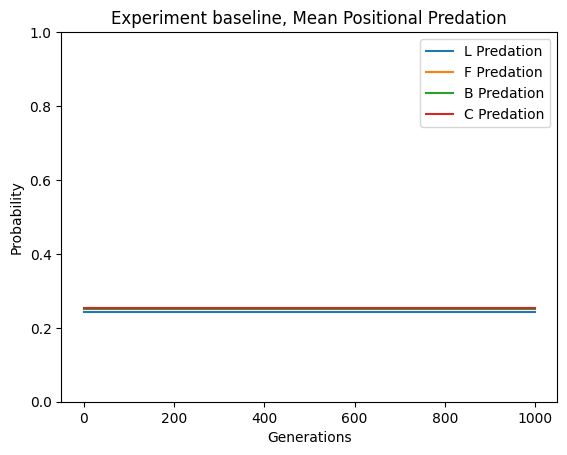

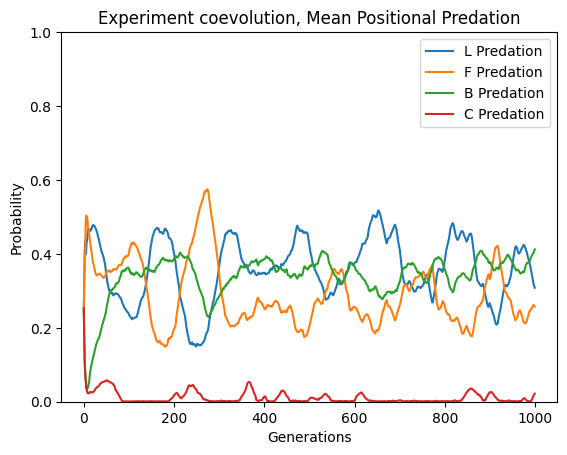

In [41]:
def plot_predation(df, title):
    plt.plot(df["X_L"], label="L Predation")
    plt.plot(df["X_F"], label="F Predation")
    plt.plot(df["X_B"], label="B Predation")
    plt.plot(df["X_C"], label="C Predation")

    plt.legend()
    plt.ylim([0,1])
    plt.xlabel("Generations")
    plt.ylabel("Probability")
    plt.title(title)

    plt.show()

def plot_env_predation(name):
    base0, base1, base2, base3 = get_coevo_runs(f"results/{name}/g1000r4/default.csv")

    avg_run = pd.DataFrame()
    avg_run["X_L"] = pd.concat([base0["X_L"], base1["X_L"], base2["X_L"], base3["X_L"]], axis=1).mean(axis=1)
    avg_run["X_F"] = pd.concat([base0["X_F"], base1["X_F"], base2["X_F"], base3["X_F"]], axis=1).mean(axis=1)
    avg_run["X_B"] = pd.concat([base0["X_B"], base1["X_B"], base2["X_B"], base3["X_B"]], axis=1).mean(axis=1)
    avg_run["X_C"] = pd.concat([base0["X_C"], base1["X_C"], base2["X_C"], base3["X_C"]], axis=1).mean(axis=1)

    plot_predation(avg_run, f"Experiment {name}, Mean Positional Predation")


plot_env_predation("baseline")
plot_env_predation("coevolution")

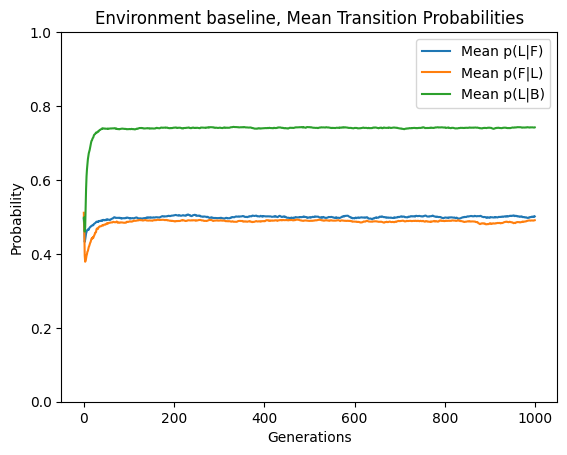

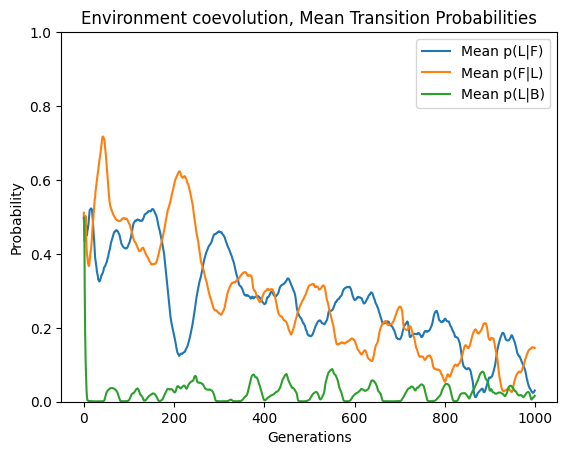

In [42]:
def plot_strategies_coevo(df, title):
    plt.plot(df["mean_p_L_given_F"], label="Mean p(L|F)")
    plt.plot(df["mean_p_F_given_L"], label="Mean p(F|L)")
    plt.plot(df["mean_p_L_given_B"], label="Mean p(L|B)")

    plt.legend()
    plt.ylim([0,1])
    plt.xlabel("Generations")
    plt.ylabel("Probability")
    plt.title(title)

    plt.show()

def plot_env_strategies_coevo(name):
    base0, base1, base2, base3 = get_coevo_runs(f"results/{name}/g1000r4/default.csv")

    avg_run = pd.DataFrame()
    avg_run["mean_p_L_given_F"] = pd.concat([base0["mean_p_L_given_F"], base1["mean_p_L_given_F"], base2["mean_p_L_given_F"], base3["mean_p_L_given_F"]], axis=1).mean(axis=1)
    avg_run["mean_p_F_given_L"] = pd.concat([base0["mean_p_F_given_L"], base1["mean_p_F_given_L"], base2["mean_p_F_given_L"], base3["mean_p_F_given_L"]], axis=1).mean(axis=1)
    avg_run["mean_p_L_given_B"] = pd.concat([base0["mean_p_L_given_B"], base1["mean_p_L_given_B"], base2["mean_p_L_given_B"], base3["mean_p_L_given_B"]], axis=1).mean(axis=1)

    plot_strategies_coevo(avg_run, f"Environment {name}, Mean Transition Probabilities")

plot_env_strategies_coevo("baseline")
plot_env_strategies_coevo("coevolution")

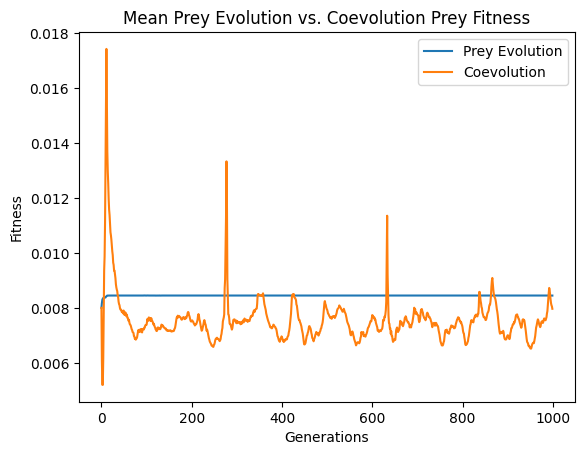

In [43]:
def plot_env_prey_fitness():
    base0, base1, base2, base3 = get_coevo_runs(f"results/baseline/g1000r4/default.csv")
    coevo0, coevo1, coevo2, coevo3 = get_coevo_runs(f"results/coevolution/g1000r4/default.csv")
    avg_run = pd.DataFrame()

    avg_run["prey_fitness"] = pd.concat([base0["prey_fitness"], base1["prey_fitness"], base2["prey_fitness"], base3["prey_fitness"]], axis=1).mean(axis=1)
    avg_run["pred_fitness"] = pd.concat([coevo0["mean_fitness"], coevo1["mean_fitness"], coevo2["mean_fitness"], coevo3["mean_fitness"]], axis=1).mean(axis=1)

    plt.plot(avg_run["prey_fitness"], label="Prey Evolution")
    plt.plot(avg_run["pred_fitness"], label="Coevolution")

    plt.legend()
    plt.xlabel("Generations")
    plt.ylabel("Fitness")
    plt.title(f"Mean Prey Evolution vs. Coevolution Prey Fitness")

    plt.show()

plot_env_prey_fitness()

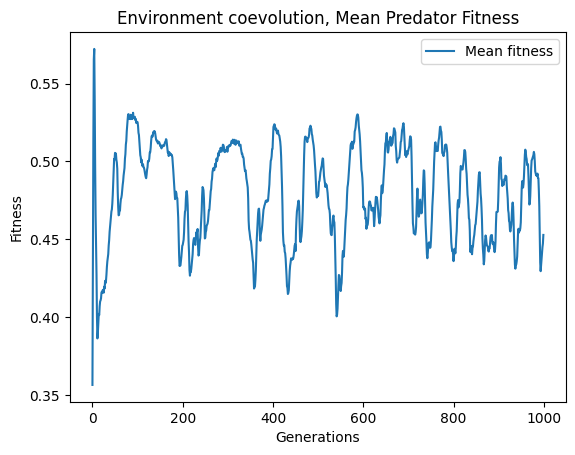

In [44]:
def plot_pred_fitness(df, title):
    plt.plot(df["mean_fitness"], label="Mean fitness")

    plt.legend()
    plt.xlabel("Generations")
    plt.ylabel("Fitness")
    plt.title(title)

    plt.show()

def plot_env_pred_fitness(name, key):
    base0, base1, base2, base3 = get_coevo_runs(f"results/{name}/g1000r4/default.csv")
    avg_run = pd.DataFrame()

    avg_run["mean_fitness"] = pd.concat([base0[key], base1[key], base2[key], base3[key]], axis=1).mean(axis=1)

    plot_pred_fitness(avg_run, f"Environment {name}, Mean Predator Fitness")

plot_env_pred_fitness("coevolution", "pred_fitness")

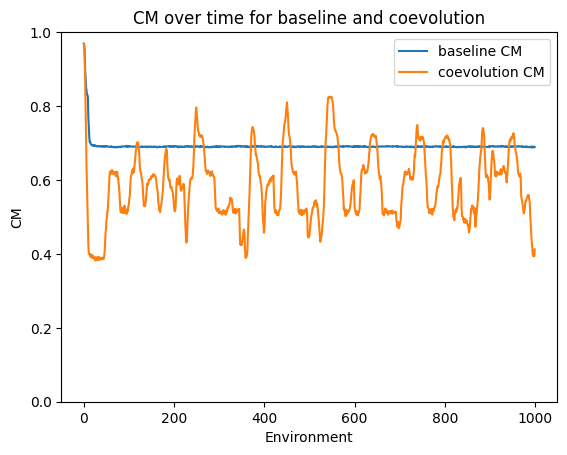

In [45]:
def plot_cm():

    for name in ["baseline", "coevolution"]:
        base0, base1, base2, base3 = get_coevo_runs(f"results/{name}/g1000r4/default.csv")
        CM = pd.concat([base0["CM"], base1["CM"], base2["CM"], base3["CM"]], axis=1).mean(axis=1)
        plt.plot(CM, label=f"{name} CM")

    # plt.legend()
    plt.xlabel("Environment")
    plt.ylim([0,1])
    plt.ylabel("CM")
    plt.title("CM over time for baseline and coevolution")
    plt.legend()

    plt.show()

plot_cm()

In [46]:
def avg_predation():
    base0, base1, base2, base3 = get_coevo_runs(f"results/baseline/g1000r4/default.csv")
    #coevo0, coevo1, coevo2, coevo3 = get_coevo_runs(f"results/coevolution/g1000r4/default.csv")

    print(base0['X_L'][0])
    print(base1['X_L'][0])
    print(base2['X_L'][0])
    print(base3['X_L'][0])

    print(f"avg X_L: {sum([base0['X_L'][0], base1['X_L'][0], base2['X_L'][0], base3['X_L'][0]]) / 4}")
    print(f"avg X_F: {sum([base0['X_F'][0], base1['X_F'][0], base2['X_F'][0], base3['X_F'][0]]) / 4}")
    print(f"avg X_B: {sum([base0['X_B'][0], base1['X_B'][0], base2['X_B'][0], base3['X_B'][0]]) / 4}")
    print(f"avg X_C: {sum([base0['X_C'][0], base1['X_C'][0], base2['X_C'][0], base3['X_C'][0]]) / 4}")

avg_predation()

0.2471632425162064
0.2657740919801813
0.2352907375833166
0.2233655163961426
avg X_L: 0.24289839711896172
avg X_F: 0.25276763783885825
avg X_B: 0.25169183308900983
avg X_C: 0.25264213195317003
